# Does Weather Affect the Stock Market? A BIST 100 Analysis
**DSA210 - Phase 1: Exploratory Data Analysis**

## 1. BIST 100 Data

In [1]:
import yfinance as yf
import pandas as pd
import os

os.makedirs("../data", exist_ok=True)

bist = yf.download("XU100.IS", start="2023-01-01", end="2024-12-31")
bist = bist[["Open", "Close", "Volume"]].copy()
bist.columns = ["open", "close", "volume"]
bist["daily_return"] = (bist["close"] - bist["open"]) / bist["open"] * 100
bist.index = pd.to_datetime(bist.index)
bist.index.name = "date"

bist.to_csv("../data/bist100.csv")
print("Saved:", len(bist), "trading days")
bist.head()

[*********************100%***********************]  1 of 1 completed

Saved: 496 trading days


,open,close,volume,daily_return
date,,,,
2023-01-02,5568.370125,5661.069824,4834734400,1.664755
2023-01-03,5697.569937,5626.570312,5459192700,-1.246139
2023-01-04,5646.570148,5523.470703,4992602800,-2.180075
2023-01-05,5555.970307,5116.372559,4510533000,-7.912169
2023-01-06,5120.972851,5341.971680,5331359700,4.315563


## 2. Istanbul Weather Data

In [2]:
import requests

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 41.0082,
    "longitude": 28.9784,
    "start_date": "2023-01-01",
    "end_date": "2024-12-31",
    "daily": "temperature_2m_mean,precipitation_sum,windspeed_10m_max",
    "format": "csv"
}

response = requests.get(url, params=params)

with open("../data/istanbul_weather.csv", "w", encoding="utf-8") as f:
    f.write(response.text)

weather = pd.read_csv("../data/istanbul_weather.csv", skiprows=3)
weather.columns = ["date", "temp_mean", "precipitation", "windspeed"]
weather["date"] = pd.to_datetime(weather["date"])
weather = weather.set_index("date")

print("Saved:", len(weather), "days")
weather.head()

Saved: 731 days


,temp_mean,precipitation,windspeed
date,,,
2023-01-01,7.6,0.0,12.2
2023-01-02,6.8,0.0,10.6
2023-01-03,6.9,0.0,17.6
2023-01-04,8.6,0.1,15.9
2023-01-05,9.4,0.0,16.6


## 3. Merge Datasets

In [3]:
df = bist.join(weather, how="inner")
df.to_csv("../data/merged.csv")
print("Merged dataset:", df.shape)
df.head()

Merged dataset: (496, 7)


,open,close,volume,daily_return,temp_mean,precipitation,windspeed
date,,,,,,,
2023-01-02,5568.370125,5661.069824,4834734400,1.664755,6.8,0.0,10.6
2023-01-03,5697.569937,5626.570312,5459192700,-1.246139,6.9,0.0,17.6
2023-01-04,5646.570148,5523.470703,4992602800,-2.180075,8.6,0.1,15.9
2023-01-05,5555.970307,5116.372559,4510533000,-7.912169,9.4,0.0,16.6
2023-01-06,5120.972851,5341.971680,5331359700,4.315563,9.4,4.0,19.5


## 4. Exploratory Data Analysis (EDA)

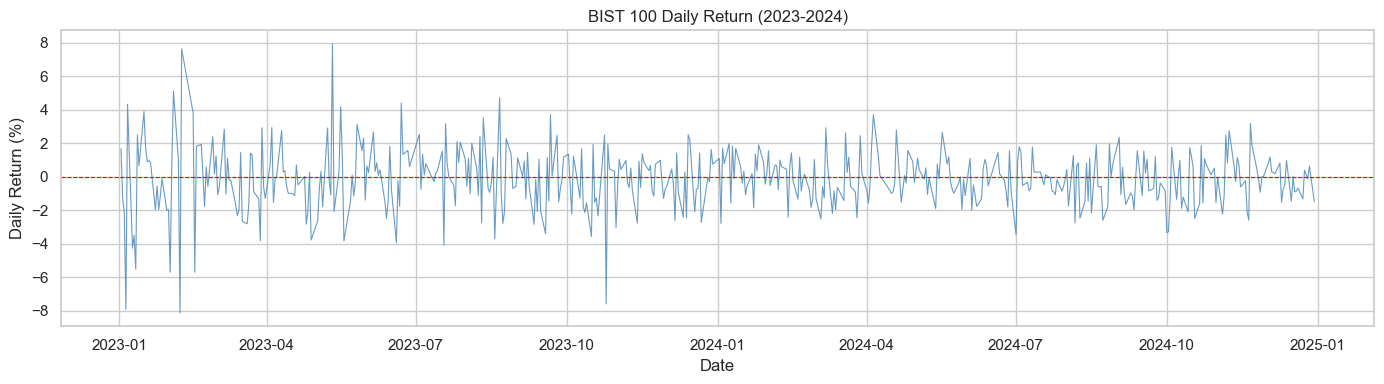

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df["daily_return"], color="steelblue", linewidth=0.8, alpha=0.8)
ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
ax.set_title("BIST 100 Daily Return (2023-2024)")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Return (%)")
plt.tight_layout()
plt.show()


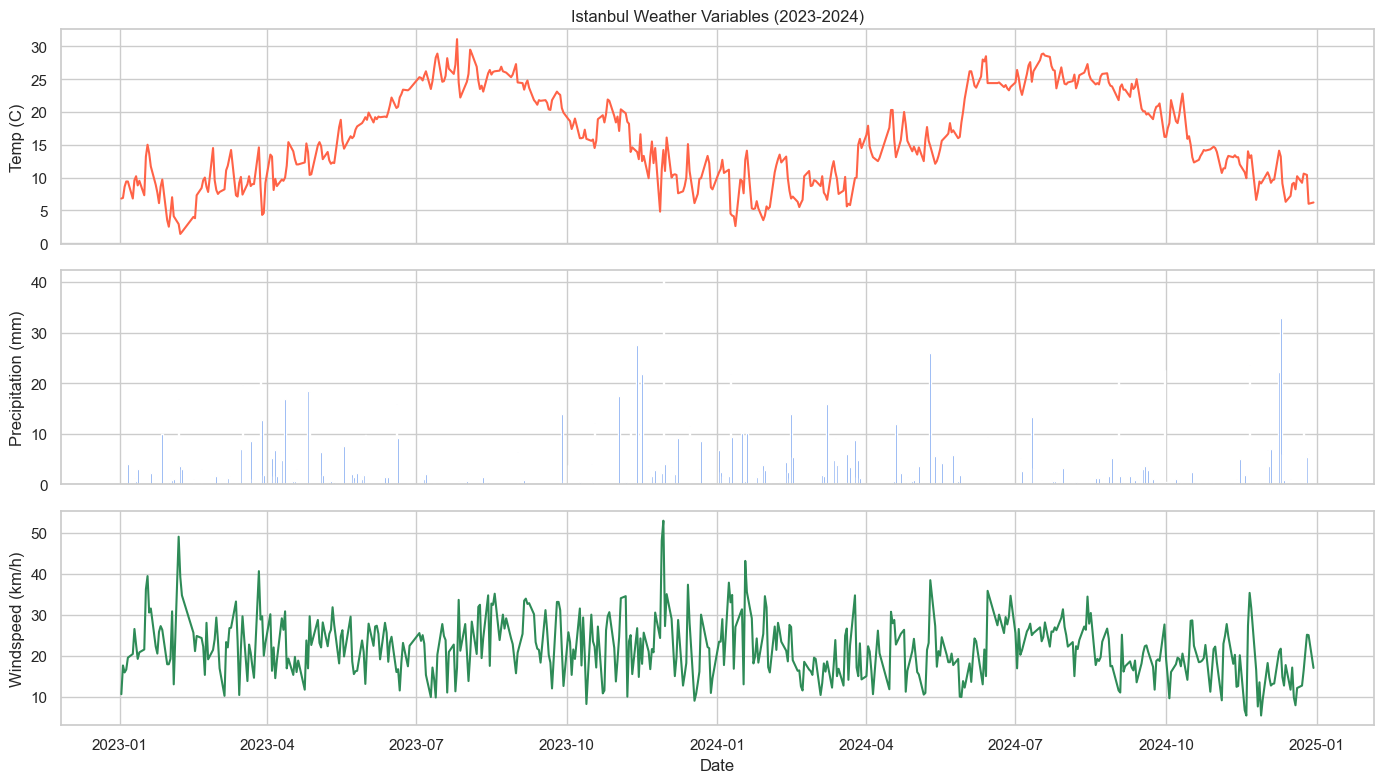

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df["temp_mean"], color="tomato")
axes[0].set_ylabel("Temp (C)")
axes[0].set_title("Istanbul Weather Variables (2023-2024)")

axes[1].bar(df.index, df["precipitation"], color="cornflowerblue", width=1)
axes[1].set_ylabel("Precipitation (mm)")

axes[2].plot(df.index, df["windspeed"], color="seagreen")
axes[2].set_ylabel("Windspeed (km/h)")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()


### Descriptive Statistics

In [6]:
# Summary statistics for all key variables
print("=== Descriptive Statistics ===\n")
df[["daily_return", "temp_mean", "precipitation", "windspeed"]].describe().round(3)

=== Descriptive Statistics ===



,daily_return,temp_mean,precipitation,windspeed
count,496.000,496.000,496.000,496.000
mean,-0.149,15.944,2.097,21.814
std,1.808,6.962,4.894,7.080
min,-8.128,1.400,0.000,5.400
25%,-1.162,10.000,0.000,16.900
50%,-0.184,14.950,0.100,21.450
75%,0.966,22.375,1.600,26.500
max,7.920,31.100,40.300,52.900


### Return Distribution

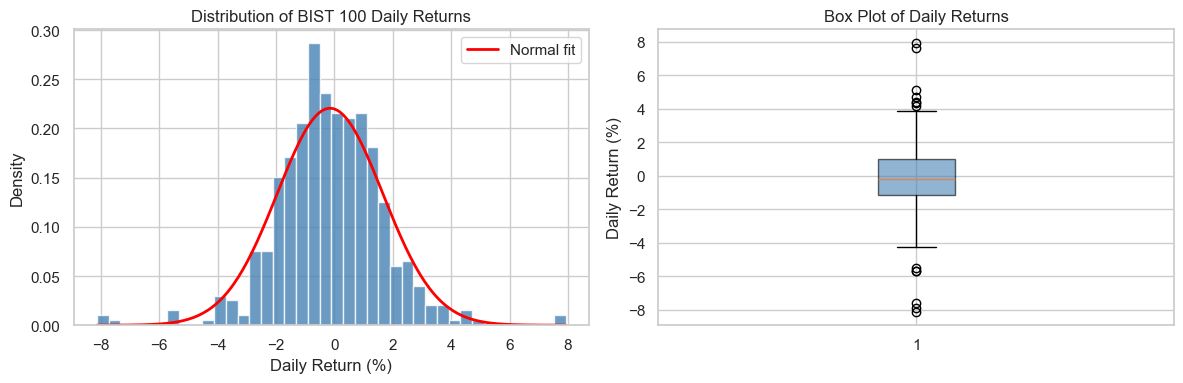

Mean:     -0.1494%
Std Dev:  1.8085%
Skewness: -0.1334
Kurtosis: 2.9365


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Distribution of daily returns — helps identify normality and outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with density curve
axes[0].hist(df["daily_return"], bins=40, color="steelblue", edgecolor="white", alpha=0.8, density=True)
x_vals = np.linspace(df["daily_return"].min(), df["daily_return"].max(), 200)
from scipy.stats import norm
mu, sigma = df["daily_return"].mean(), df["daily_return"].std()
axes[0].plot(x_vals, norm.pdf(x_vals, mu, sigma), color="red", linewidth=2, label="Normal fit")
axes[0].set_title("Distribution of BIST 100 Daily Returns")
axes[0].set_xlabel("Daily Return (%)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Box plot — shows median, IQR, and outliers
axes[1].boxplot(df["daily_return"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_title("Box Plot of Daily Returns")
axes[1].set_ylabel("Daily Return (%)")

plt.tight_layout()
plt.show()

print(f"Mean:     {df['daily_return'].mean():.4f}%")
print(f"Std Dev:  {df['daily_return'].std():.4f}%")
print(f"Skewness: {df['daily_return'].skew():.4f}")
print(f"Kurtosis: {df['daily_return'].kurtosis():.4f}")

### Scatter Plots: Weather vs Daily Return

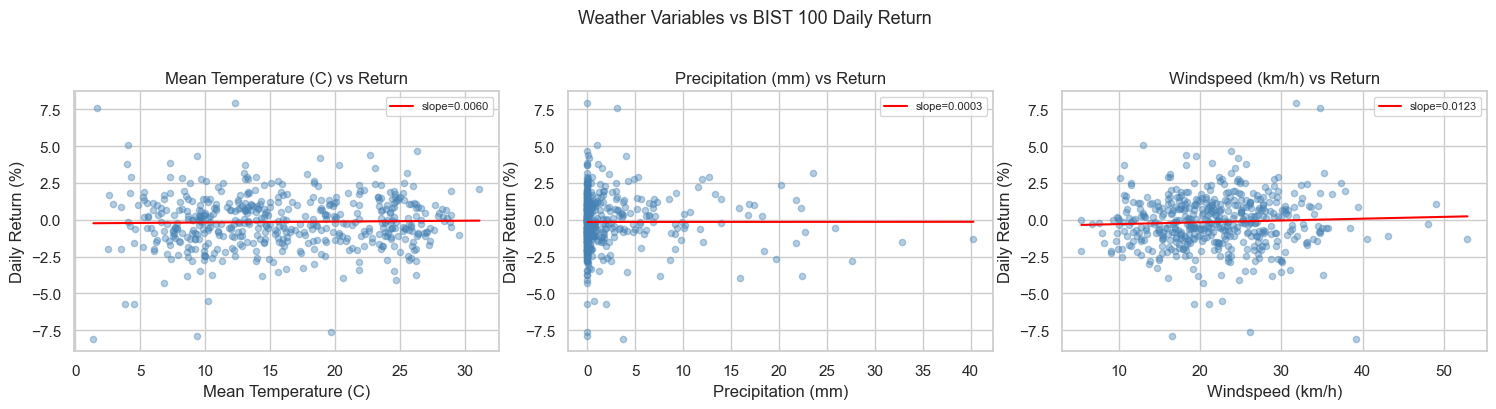

In [8]:
# Scatter plots show the raw relationship between each weather variable and market returns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

weather_vars = ["temp_mean", "precipitation", "windspeed"]
labels = ["Mean Temperature (C)", "Precipitation (mm)", "Windspeed (km/h)"]

for ax, var, label in zip(axes, weather_vars, labels):
    ax.scatter(df[var], df["daily_return"], alpha=0.4, s=20, color="steelblue")
    # Fit a linear regression line to visualize trend direction
    m, b = np.polyfit(df[var], df["daily_return"], 1)
    x_range = np.linspace(df[var].min(), df[var].max(), 100)
    ax.plot(x_range, m * x_range + b, color="red", linewidth=1.5, label=f"slope={m:.4f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Daily Return (%)")
    ax.set_title(f"{label} vs Return")
    ax.legend(fontsize=8)

plt.suptitle("Weather Variables vs BIST 100 Daily Return", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Correlation Heatmap

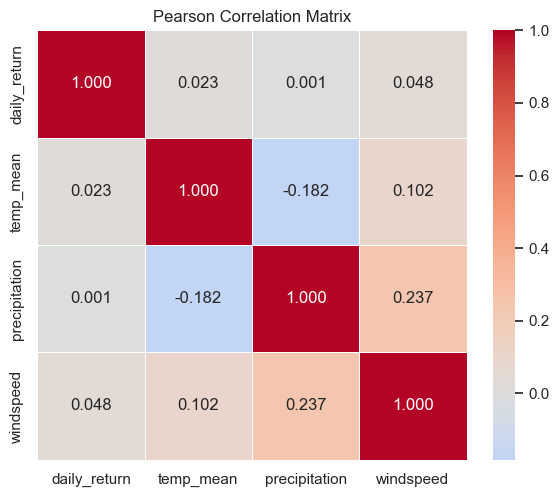

Note: Values close to 0 indicate weak linear relationships.


In [9]:
# Correlation matrix — measures linear association between all pairs of variables
corr = df[["daily_return", "temp_mean", "precipitation", "windspeed"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

print("Note: Values close to 0 indicate weak linear relationships.")